СР 2 вариант

1 задания : графически отделить

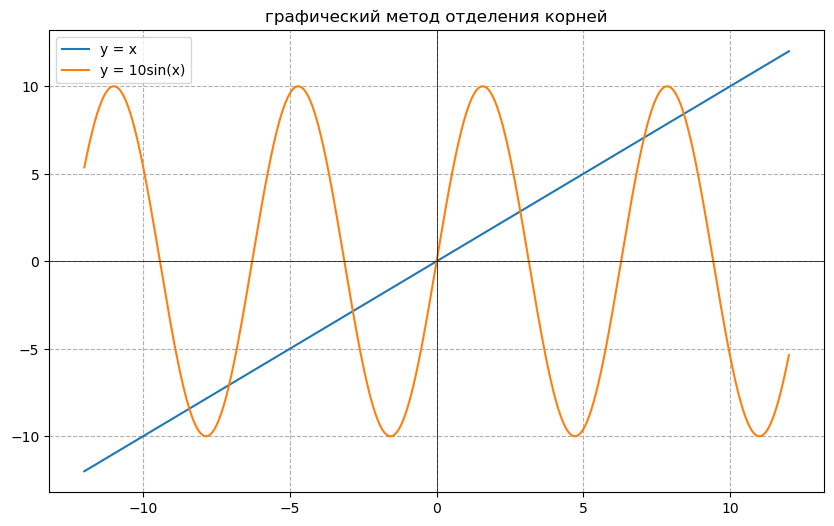

In [4]:
import numpy as np
import matplotlib.pyplot as plt

#массив точек для графика
x = np.linspace(-12, 12, 1000)

y1 = x
y2 = 10 * np.sin(x)

#визуализация
plt.figure(figsize=(10, 6))
plt.plot(x, y1, label='y = x')
plt.plot(x, y2, label='y = 10sin(x)')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle='--')
plt.legend()
plt.title('графический метод отделения корней')
plt.show()

2 задание точность е=3 метод половиного деления

In [5]:
def f(x):
    return x - 10 * np.sin(x)

#берем отрезок от 2 до 3 где есть корень
a = 2.0
b = 3.0
eps = 1e-3

#цикл деления пополам
while (b - a) / 2 > eps:
    c = (a + b) / 2
    if f(a) * f(c) < 0:
        b = c
    else:
        a = c

print(f"корень методом дихотомии: {(a + b) / 2:.4f}")


корень методом дихотомии: 2.8525


3 задание : простой итерации е=6

In [5]:
def iteration_method(x0, eps):
    tau = 0.05 #коэф сходимости
    x_curr = x0
    
    while True:
        #считаем по формуле
        x_next = x_curr - tau * (x_curr - 10 * np.sin(x_curr))
        
        #проверка точносии
        if abs(x_next - x_curr) < eps:
            break
        x_curr = x_next
        
    return x_next

#запуск функции с начальным приближением
r = iteration_method(2.8, 1e-6)
print(f"корень методом итераций: {r:.7f}")



корень методом итераций: 2.8523412


4 задание комбинированный метод

In [6]:
from numpy import *

def f(x):
    return x-10*sin(x)

def df(x): #производная
    return 1-10*cos(x)

#начальные границы
a = 2.0
b = 3.0
eps = 1e-6

def combined_solve(a, b, e):
    x_h = a #для хорд
    x_k = b #для кас
    
    while abs(x_k - x_h) > e:
        #со стороны хорд
        x_h = x_h - (f(x_h)*(x_k - x_h))/(f(x_k) - f(x_h))
        #со стороны кас
        x_k = x_k - f(x_k)/df(x_k)
        
    return (x_h + x_k) / 2

root_comb = combined_solve(a, b, eps)
print(f"корень через комбинированный метод: {root_comb:.7f}")

корень через комбинированный метод: 2.8523419


5 задание

Найденный корень: 2.8523418944


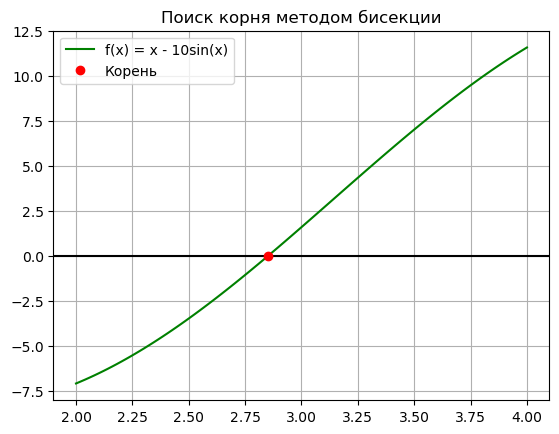

In [7]:
from matplotlib.pyplot import *

f = lambda x: x - 10 * sin(x)

def bisection(a, b, tol=1e-10):
    while (b - a) > tol:
        mid = (a + b) / 2
        #сдвигаю границы
        if f(a) * f(mid) < 0: 
            b = mid
        else: 
            a = mid
    return (a + b) / 2

# корень на интервале 2 т 3
root = bisection(2, 3)
print(f"Найденный корень: {root:.10f}")

#визуализация
x_axis = linspace(2, 4, 100)
y_axis = f(x_axis)
plot(x_axis, y_axis, 'g', label='f(x) = x - 10sin(x)') 
axhline(0, color='black')            
plot(root, 0, 'ro', label='Корень')            
title('Поиск корня методом бисекции')
grid(True)
legend()
show()